In [1]:
import scdrs
import scanpy as sc
sc.set_figure_params(dpi=125)
from anndata import AnnData
from scipy import stats
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings

warnings.filterwarnings("ignore")

In [2]:
#use python3.11-anaconda/2024.02 and Python (scdrs_env) kernel to use this

In [3]:
# load adata
adata = sc.read_h5ad("/scratch/scjp_root/scjp1/christav/fap_village_multiome/results/RNA_clustering/rna_final.h5ad")

In [4]:
if not isinstance(adata.obsm['X_umap'], np.ndarray):
    adata.obsm['X_umap'] = adata.obsm['X_umap'].to_numpy()

In [5]:
df_gs = ["PASS_ADHD_Demontis2018","PASS_Alzheimers_Jansen2019","PASS_AtrialFibrillation_Nielsen2018","PASS_BIP_Mullins2021","PASS_CD_deLange2017","PASS_Celiac","PASS_Coronary_Artery_Disease","PASS_DrinksPerWeek_Liu2019","PASS_FastingGlucose_Manning","PASS_GeneralRiskTolerance_KarlssonLinner2019","PASS_IBD_deLange2017","PASS_Insomnia_Jansen2019","PASS_Intelligence_SavageJansen2018","PASS_Lupus","PASS_MDD_Howard2019","PASS_Multiple_sclerosis","PASS_Primary_biliary_cirrhosis","PASS_ReactionTime_Davies2018","PASS_Rheumatoid_Arthritis","PASS_SWB","PASS_Schizophrenia_Pardinas2018","PASS_SleepDuration_Dashti2019","PASS_Type_1_Diabetes","PASS_Type_2_Diabetes","PASS_UC_deLange2017","PASS_VerbalNumericReasoning_Davies2018","PASS_Worry_Nagel2018","UKB_460K.biochemistry_AlanineAminotransferase","UKB_460K.biochemistry_AlkalinePhosphatase","UKB_460K.biochemistry_Cholesterol","UKB_460K.biochemistry_Glucose","UKB_460K.biochemistry_HDLcholesterol","UKB_460K.biochemistry_HbA1c","UKB_460K.biochemistry_LDLdirect","UKB_460K.biochemistry_SHBG","UKB_460K.biochemistry_Testosterone_Male","UKB_460K.biochemistry_TotalBilirubin","UKB_460K.biochemistry_TotalProtein","UKB_460K.biochemistry_Triglycerides","UKB_460K.blood_EOSINOPHIL_COUNT","UKB_460K.blood_LYMPHOCYTE_COUNT","UKB_460K.blood_MEAN_CORPUSCULAR_HEMOGLOBIN","UKB_460K.blood_MONOCYTE_COUNT","UKB_460K.blood_PLATELET_COUNT","UKB_460K.blood_RBC_DISTRIB_WIDTH","UKB_460K.blood_RED_COUNT","UKB_460K.blood_WHITE_COUNT","UKB_460K.bmd_HEEL_TSCOREz","UKB_460K.body_BALDING1","UKB_460K.body_BMIz","UKB_460K.body_HEIGHTz","UKB_460K.body_WHRadjBMIz","UKB_460K.bp_DIASTOLICadjMEDz","UKB_460K.bp_SYSTOLICadjMEDz","UKB_460K.cancer_BREAST","UKB_460K.cov_EDU_COLLEGE","UKB_460K.cov_EDU_YEARS","UKB_460K.cov_SMOKING_STATUS","UKB_460K.disease_AID_ALL","UKB_460K.disease_ALLERGY_ECZEMA_DIAGNOSED","UKB_460K.disease_ASTHMA_DIAGNOSED","UKB_460K.disease_CARDIOVASCULAR","UKB_460K.disease_HYPERTENSION_DIAGNOSED","UKB_460K.disease_HYPOTHYROIDISM_SELF_REP","UKB_460K.disease_RESPIRATORY_ENT","UKB_460K.impedance_BASAL_METABOLIC_RATEz","UKB_460K.lung_FEV1FVCzSMOKE","UKB_460K.lung_FVCzSMOKE","UKB_460K.mental_NEUROTICISM","UKB_460K.other_MORNINGPERSON","UKB_460K.pigment_HAIR","UKB_460K.repro_MENARCHE_AGE","UKB_460K.repro_MENOPAUSE_AGE","UKB_460K.repro_NumberChildrenEverBorn_Pooled"]

dict_score = {
    trait: pd.read_csv(f"compute_score_out/{trait}.full_score.gz", sep="\t", index_col=0)
    for trait in df_gs
}

for trait in dict_score:
    adata.obs[trait] = dict_score[trait]["norm_score"]

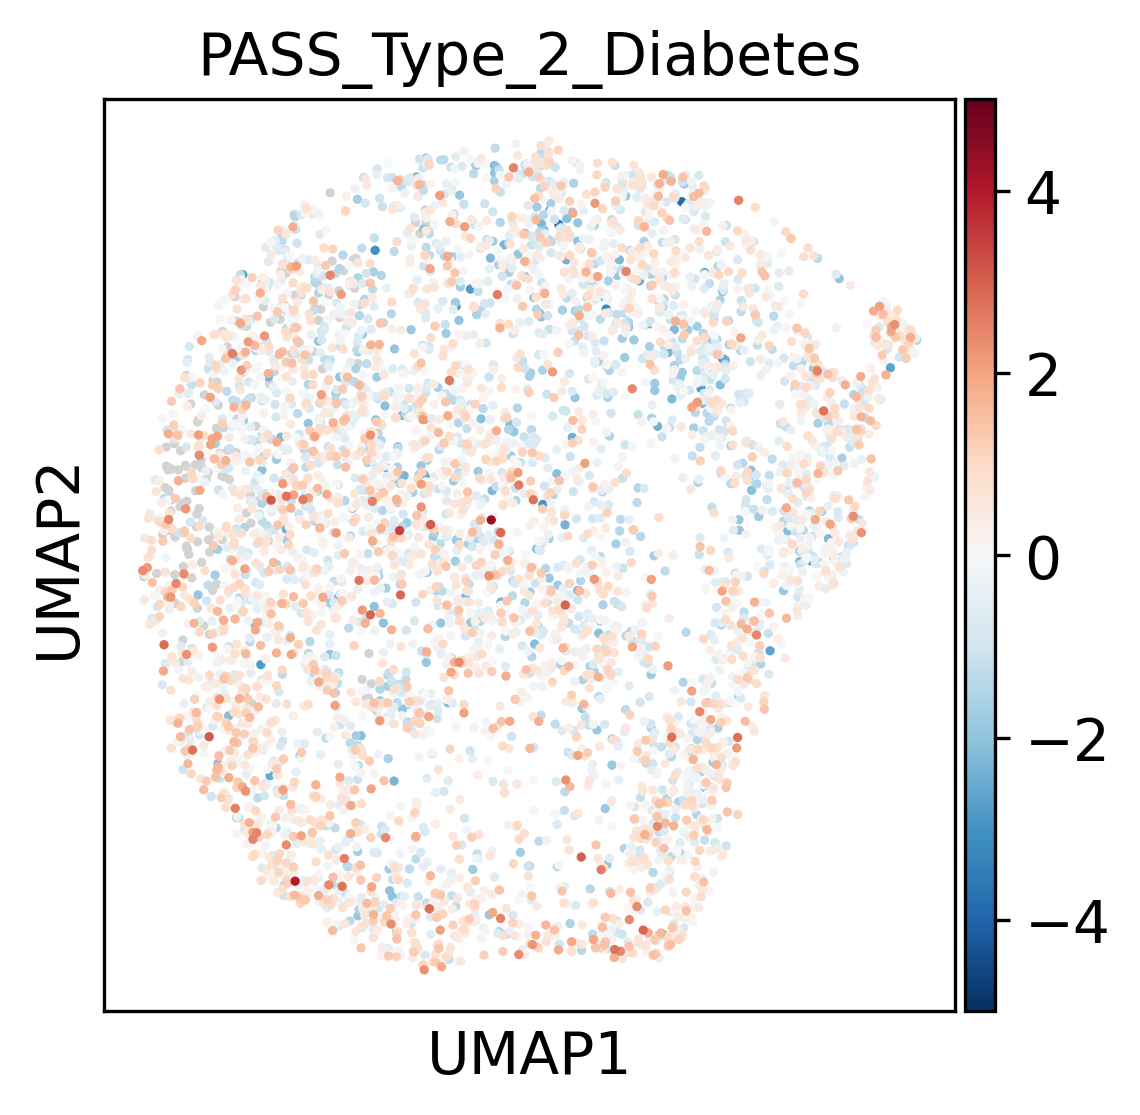

In [11]:
sc.set_figure_params(figsize=[4, 4], dpi=150)
#sc.pl.umap(
#    adata,
#    color="enviro",
#    ncols=1,
#    color_map="RdBu_r",
#    vmin=-5,
#    vmax=5,
#)

sc.pl.umap(
    adata,
    color="PASS_Type_2_Diabetes",
    color_map="RdBu_r",
    vmin=-5,
    vmax=5,
    s=20,
    save="_t2d_final.png"
)

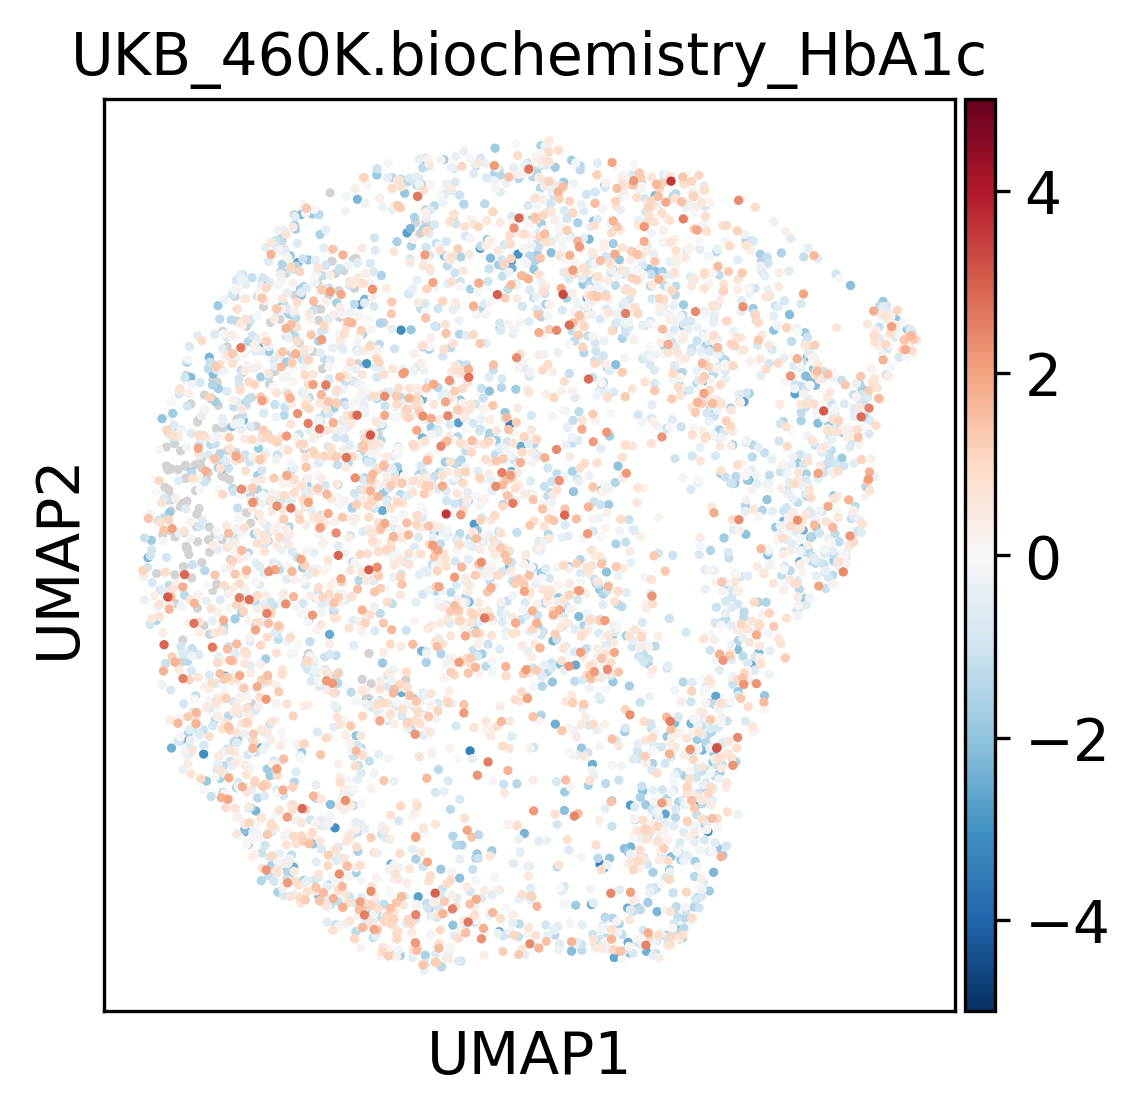

In [15]:
sc.set_figure_params(figsize=[4, 4], dpi=150)

sc.pl.umap(
    adata,
    color="UKB_460K.biochemistry_HbA1c",
    color_map="RdBu_r",
    vmin=-5,
    vmax=5,
    s=20,
    save="_hba1c_final.png"
)

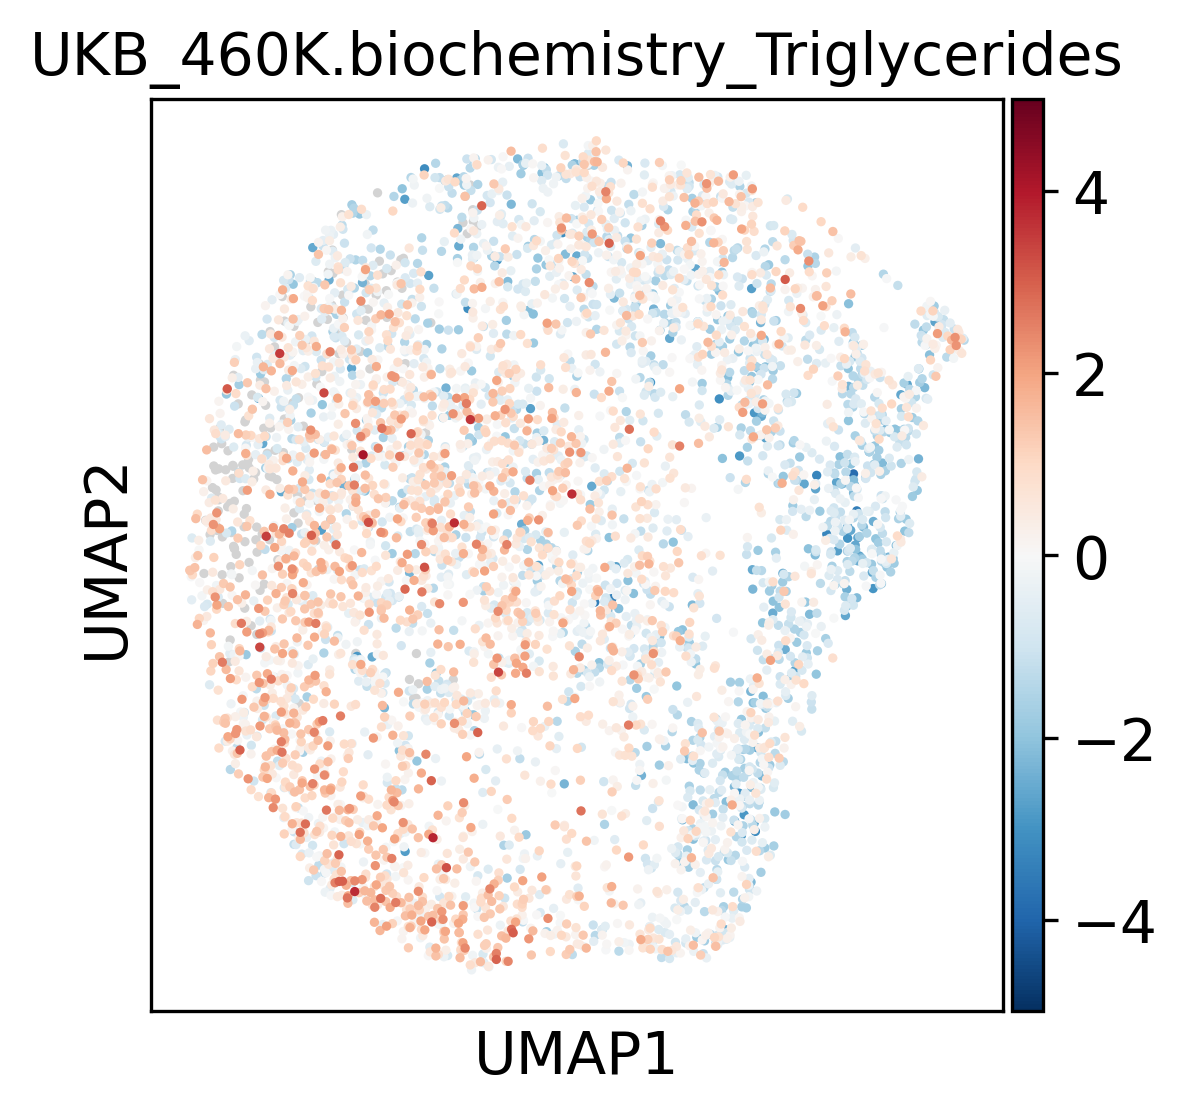

In [12]:
sc.set_figure_params(figsize=[4, 4], dpi=150)

sc.pl.umap(
    adata,
    color="UKB_460K.biochemistry_Triglycerides",
    color_map="RdBu_r",
    vmin=-5,
    vmax=5,
    s=20,
    save="_triglycerides_final.png"
)

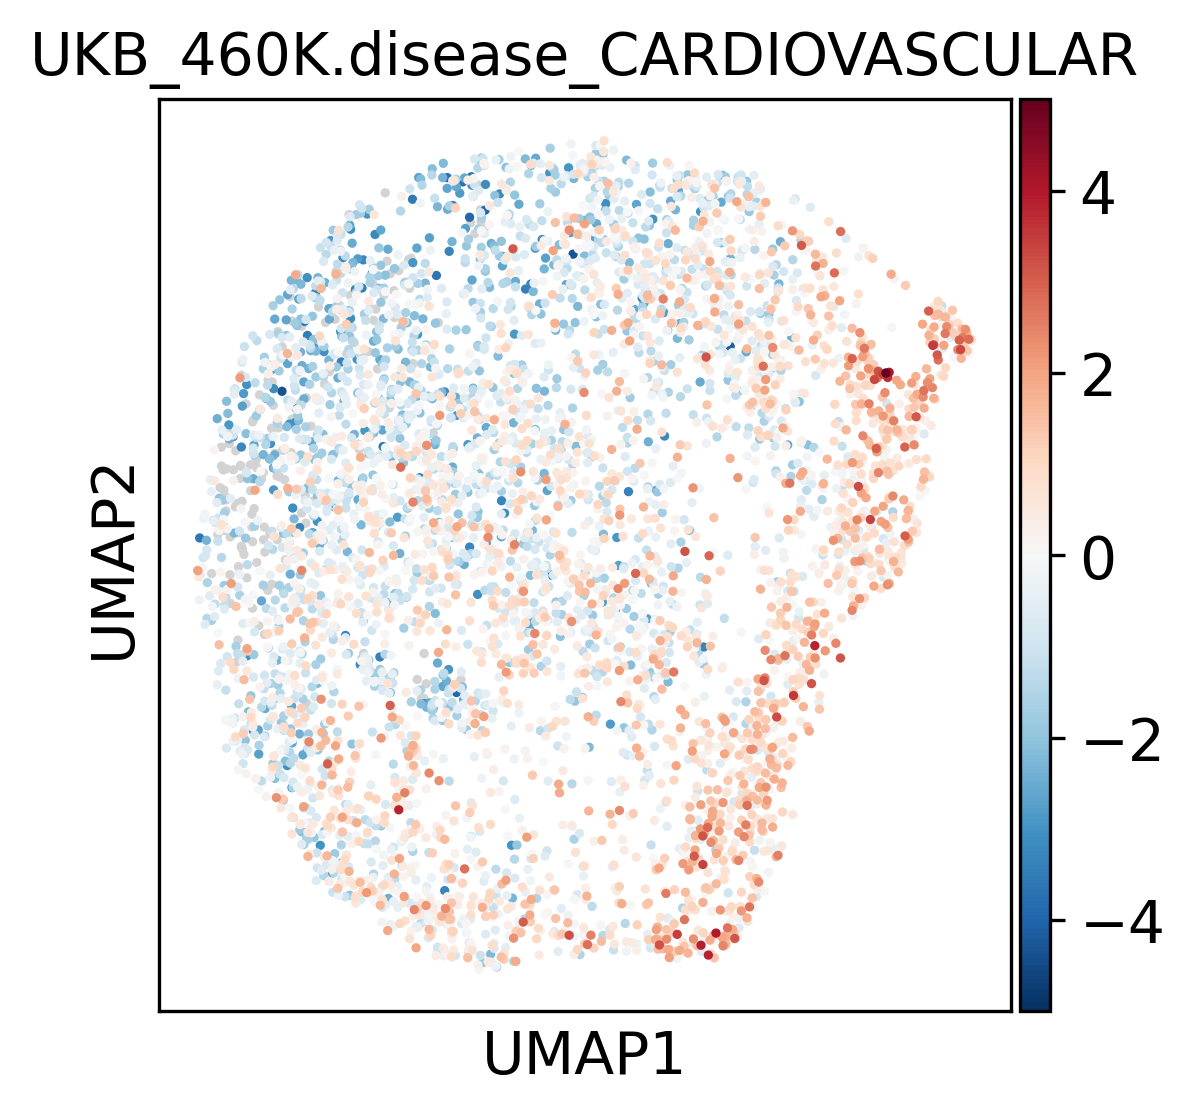

In [13]:
sc.set_figure_params(figsize=[4, 4], dpi=150)

sc.pl.umap(
    adata,
    color="UKB_460K.disease_CARDIOVASCULAR",
    color_map="RdBu_r",
    vmin=-5,
    vmax=5,
    s=20,
    save="_cardiovasc_final.png"
)

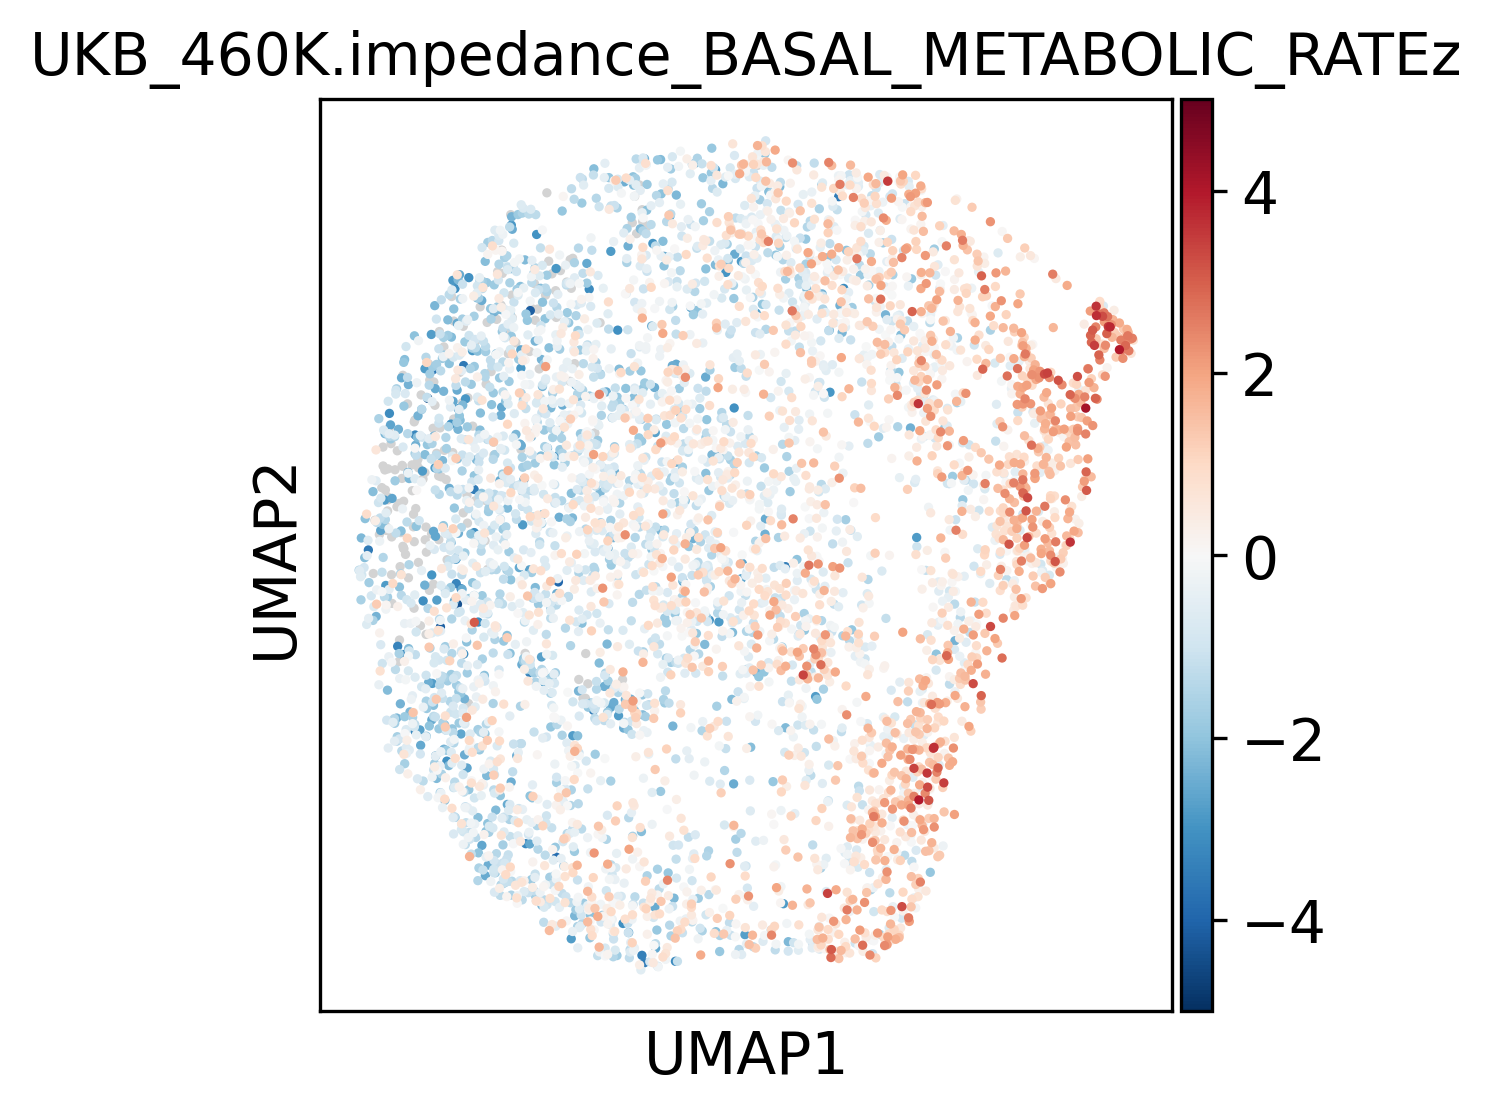

In [14]:
sc.set_figure_params(figsize=[4, 4], dpi=150)

sc.pl.umap(
    adata,
    color="UKB_460K.impedance_BASAL_METABOLIC_RATEz",
    color_map="RdBu_r",
    vmin=-5,
    vmax=5,
    s=20,
    save="_metabolic_final.png"
)